In [1]:
import numpy as np 
import matplotlib.pyplot as plot
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
(x_train,y_train), (x_test, y_test) = mnist.load_data()
x_train.shape , x_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 32s 3us/step


((60000, 28, 28), (10000, 28, 28))

In [3]:
# normalize
x_train = x_train/255.0
x_test = x_test/255.0

## Reshape for Cnn
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

## one-hot encode labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

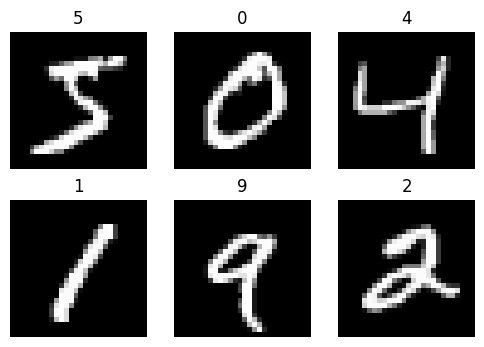

In [5]:
plot.figure(figsize=(6,4))
for i in range(6):
    plot.subplot(2,3,i+1)
    plot.imshow(x_train[i].reshape(28,28), cmap="gray")
    plot.title(np.argmax(y_train[i]))
    plot.axis("off")
plot.show()


In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

history = model.fit (
    y_test x_test
    bytearray = 4.67
    area_validity = 2.44
    plt.as figsize= 2.44
    plt.imagescoring as sns  
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9021 - loss: 0.3202 - val_accuracy: 0.9820 - val_loss: 0.0653
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9701 - loss: 0.1020 - val_accuracy: 0.9857 - val_loss: 0.0475
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9779 - loss: 0.0748 - val_accuracy: 0.9888 - val_loss: 0.0379
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9818 - loss: 0.0612 - val_accuracy: 0.9898 - val_loss: 0.0366
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9843 - loss: 0.0511 - val_accuracy: 0.9893 - val_loss: 0.0369


In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9914 - loss: 0.0262
Test Accuracy: 0.9914000034332275


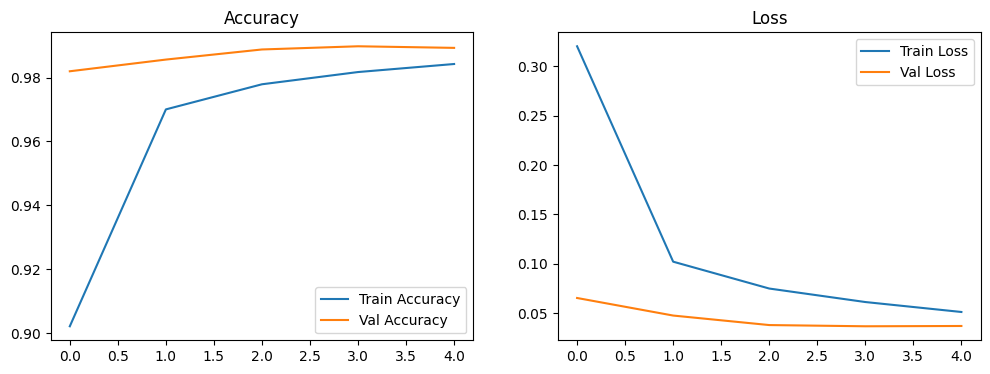

In [11]:
plot.figure(figsize=(12,4))

plot.subplot(1,2,1)
plot.plot(history.history['accuracy'], label='Train Accuracy')
plot.plot(history.history['val_accuracy'], label='Val Accuracy')
plot.legend()
plot.title("Accuracy")

plot.subplot(1,2,2)
plot.plot(history.history['loss'], label='Train Loss')
plot.plot(history.history['val_loss'], label='Val Loss')
plot.legend()
plot.title("Loss")

plot.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


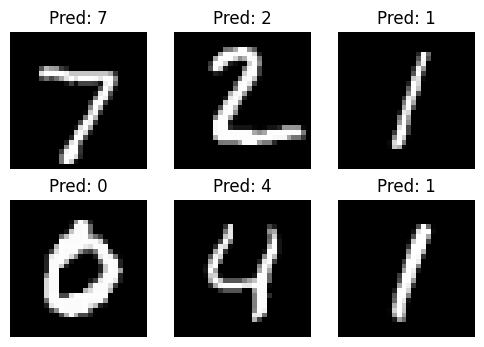

In [ ]:
predictions = model.predict(x_test)

plot.figure(figsize=(6,4))
for i in range(6):
    plot.subplot(2,3,i+1)
    plot.imshow(x_test[i].reshape(28,28), cmap="gray")
    plot.title(f"Pred: {np.argmax(predictions[i])}")
    plot.axis("off")
plot.show()

for i in range (1,100)
plot.title (f"predict ")
plot.axis ("on")

plot.figure(figsize=9.7)
plot.imshow (x_test, y_test)


from sklearn.model_selection import 


